<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_2_Accessing_Text_Corpora_and_Lexical_Resources.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing the required libraries
!pip install nltk wordcloud matplotlib

# Importing them libraries
import nltk
from nltk.corpus import opinion_lexicon, wordnet
from nltk.probability import ConditionalFreqDist
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
# Downloading the required datasets
nltk.download('opinion_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Loading the positive and negative words
positive_words = list(opinion_lexicon.positive())
negative_words = list(opinion_lexicon.negative())

print('Number of positive words:', len(positive_words))
print('Number of negative words:', len(negative_words))

print('\nFirst 20 Positive Words:')
print(positive_words[:20])

print('\nFirst 20 Negative Words:')
print(negative_words[:20])

Number of positive words: 2006
Number of negative words: 4783

First 20 Positive Words:
['a+', 'abound', 'abounds', 'abundance', 'abundant', 'accessable', 'accessible', 'acclaim', 'acclaimed', 'acclamation', 'accolade', 'accolades', 'accommodative', 'accomodative', 'accomplish', 'accomplished', 'accomplishment', 'accomplishments', 'accurate', 'accurately']

First 20 Negative Words:
['2-faced', '2-faces', 'abnormal', 'abolish', 'abominable', 'abominably', 'abominate', 'abomination', 'abort', 'aborted', 'aborts', 'abrade', 'abrasive', 'abrupt', 'abruptly', 'abscond', 'absence', 'absent-minded', 'absentee', 'absurd']


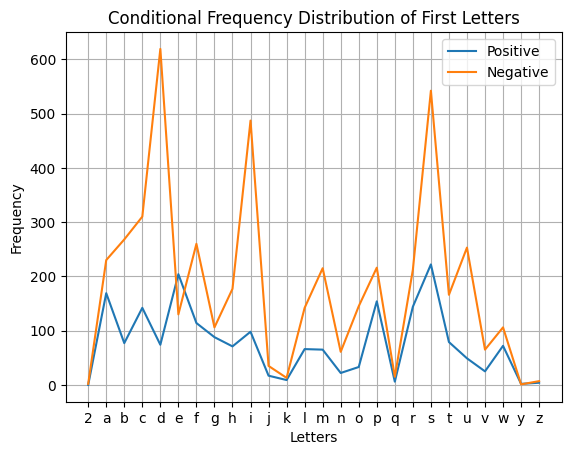

In [ ]:
# The Conditional Frequency Distribution
cfd = ConditionalFreqDist()

for word in positive_words:
    cfd['Positive'][word[0].lower()] += 1

for word in negative_words:
    cfd['Negative'][word[0].lower()] += 1

letters = sorted(set([w[0].lower() for w in positive_words + negative_words]))

positive_counts = [cfd['Positive'][l] for l in letters]
negative_counts = [cfd['Negative'][l] for l in letters]

plt.figure()
plt.plot(letters, positive_counts, label='Positive')
plt.plot(letters, negative_counts, label='Negative')

plt.title('Conditional Frequency Distribution of First Letters')
plt.xlabel('Letters')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

Positive Word Cloud


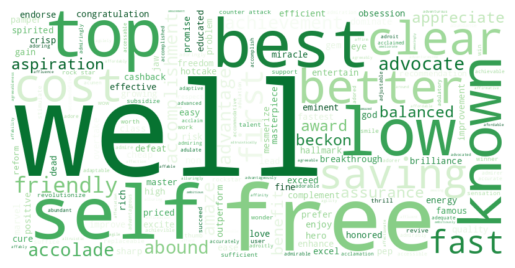

Negative Word Cloud


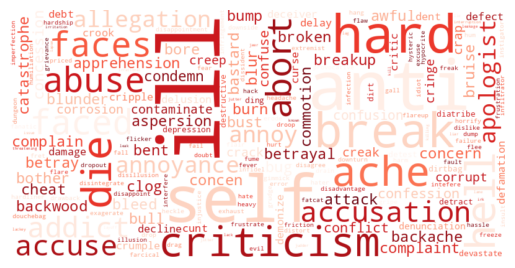

In [ ]:
# Word Cloud Function
def generate_wordcloud(words, color):
    text = ' '.join(words)
    wc = WordCloud(width=800, height=400, background_color='white', colormap=color).generate(text)
    plt.figure()
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.show()

print('Positive Word Cloud')
generate_wordcloud(positive_words, 'Greens')

print('Negative Word Cloud')
generate_wordcloud(negative_words, 'Reds')

In [ ]:
# Synonyms and Antonyms Function
def get_syn_ant(word):
    synonyms = set()
    antonyms = set()

    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonyms.add(lemma.name())
            if lemma.antonyms():
                antonyms.add(lemma.antonyms()[0].name())

    print('\nWord:', word)
    print('Synonyms:', synonyms)
    print('Antonyms:', antonyms)

    print('\n--- Lexicon Check ---')
    for s in synonyms:
        if s in positive_words:
            print(s, '-> Positive')
        elif s in negative_words:
            print(s, '-> Negative')

    for a in antonyms:
        if a in positive_words:
            print(a, '-> Positive')
        elif a in negative_words:
            print(a, '-> Negative')

In [ ]:
# Testing of the synonyms and antonyms
get_syn_ant('good')
get_syn_ant('bad')
get_syn_ant('happy')


Word: good
Synonyms: {'skillful', 'unspoiled', 'salutary', 'serious', 'ripe', 'honest', 'goodness', 'dear', 'effective', 'dependable', 'estimable', 'beneficial', 'skilful', 'good', 'upright', 'respectable', 'just', 'practiced', 'well', 'undecomposed', 'safe', 'thoroughly', 'adept', 'in_force', 'trade_good', 'near', 'right', 'sound', 'honorable', 'secure', 'commodity', 'unspoilt', 'soundly', 'full', 'proficient', 'expert', 'in_effect'}
Antonyms: {'bad', 'ill', 'evil', 'badness', 'evilness'}

--- Lexicon Check ---
skillful -> Positive
salutary -> Positive
honest -> Positive
goodness -> Positive
effective -> Positive
dependable -> Positive
beneficial -> Positive
good -> Positive
respectable -> Positive
well -> Positive
safe -> Positive
right -> Positive
honorable -> Positive
secure -> Positive
soundly -> Positive
proficient -> Positive
bad -> Negative
evil -> Negative

Word: bad
Synonyms: {'defective', 'sorry', 'forged', 'regretful', 'bad', 'unsound', 'spoilt', 'speculative', 'spoiled', 

In [ ]:
# Word Classification Function
def classify_word(word):
    word = word.lower()
    if word in positive_words:
        return 'Positive'
    elif word in negative_words:
        return 'Negative'
    else:
        return 'Neutral'

test_words = ['good','amazing','terrible','ugly','nice','awful','clean','dirty','happy','neutral']

for word in test_words:
    print(word, ':', classify_word(word))

good : Positive
amazing : Positive
terrible : Negative
ugly : Negative
nice : Positive
awful : Negative
clean : Positive
dirty : Negative
happy : Positive
neutral : Neutral
